#### 환경 설정

In [1]:
import os

ROOT_DIR = os.getcwd()

# 코랩 모드
if ROOT_DIR == "/content":
    print("[[ colab ]]")
    
    import unicodedata
    
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    TEXT_DIR = os.path.join(ROOT_DIR, "raw")

    if "raw.tar.gz" not in os.listdir():
        # subprocess()
        !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
    else:
        print("· raw.tar.gz (O)")


    if not os.path.exists(TEXT_DIR):
        !tar -xzvf raw.tar.gz -C /content
    else:
        print("· data (O)")


    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)


    train_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_valid_set.json")

    train_json_path = unicodedata.normalize("NFC", train_json_path)
    val_json_path = unicodedata.normalize("NFC", val_json_path)

# 로컬 모드
else:
    print("[[ local ]]")
    
    DATA_DIR = os.path.join(ROOT_DIR, "data")

    train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

[[ colab ]]
--2026-01-12 16:32:50--  https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1095771901/8725ebcb-07a0-4575-8052-79f3a00f0a2d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-12T17%3A10%3A46Z&rscd=attachment%3B+filename%3Draw.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-12T16%3A09%3A53Z&ske=2026-01-12T17%3A10%3A46Z&sks=b&skv=2018-11-09&sig=F%2BOsk6VD3M7jghRtJoeZAhvSsekcskVYxWB10jwmD5Q%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2ODIzOTE3MCwibmJmIjoxNzY4MjM1NTcwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi

In [2]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


---

# 목표

번역기 만들기

In [3]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

train_data = train_data["data"]

### 샘플 출력

In [4]:
import random

rand_idx = random.randint(1, len(train_data)) - 1

train_data[rand_idx]

{'sn': 'CUSCHAEGKG062119042902897',
 'data_set': '일상생활및구어체',
 'domain': '해외고객과의채팅',
 'subdomain': '연구개발,과학기술',
 'ko_original': '제가 보통 오전에는 연락이 어려워서요.',
 'ko': '제가 보통 오전에는 연락이 어려워서요.',
 'mt': "It's usually hard for me to contact you in the morning.",
 'en': "It's usually difficult for me to contact you first thing in the morning.",
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 5,
 'word_count_en': 13,
 'word_ratio': 2.6,
 'file_name': 'CUSCHA_EGKG.xlsx',
 'source': '크라우드소싱',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': None}

ner은 Named Entity Recognition. 꼭 살려둬야 한다.

In [5]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in train_data[0].keys()}

for i, dict_ in enumerate(train_data):   
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'일상생활', '해외고객과의채팅', '해외영업'}
· subdomain: 11개
    - {'부동산', '정보통신', '음식', '예약', '금융,보험', '기계장비,의료정밀', '연구개발,과학기술', '구매', '도소매유통', '숙박,음식점', '여행'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'INTSAL_STRS.xlsx', '구매_KPUS.xlsx', 'INTSAL_FNIN.xlsx', 'CUSCHA_FNIN.xlsx', 'CUSCHA_DSUT.xlsx', '음식_KFDS.xlsx', 'INTSAL_MCHO.xlsx', 'INTSAL_JBTS.xlsx', 'INTSAL_DSUT.xlsx', 'CUSCHA_EGKG.xlsx', 'CUSCHA_RLST.xlsx', 'CUSCHA_MCHO.xlsx', 'INTSAL_RLST.xlsx', '예약_KRSS.xlsx', 'CUSCHA_JBTS.xlsx', 'CUSCHA_STRS.xlsx', '여행_KTOS.xlsx', 'INTSAL_EGKG.xlsx'}
· source: 2개
    - {'SBS', '크라우드소싱'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


### 중복치

domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

번역본끼리 한 쌍, 원본끼리 한 쌍으로 묶는다.

In [6]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style", 
    "included_unknown_words", "file_name", 
    "source_language", "target_language"
    ]

useful_list = [column for column in list(train_data[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(train_data, columns=useful_list)

In [7]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

train_df = train_df.drop(["ko", "mt"], axis=1)

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


### 극단치

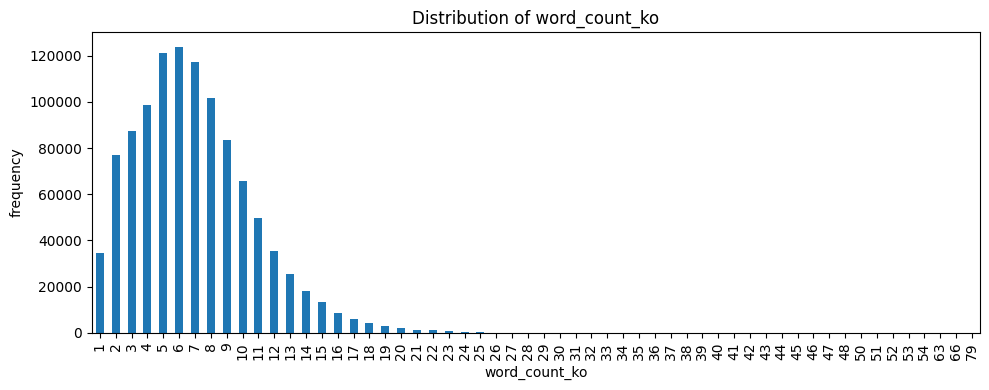

In [8]:
# word_count_ko
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

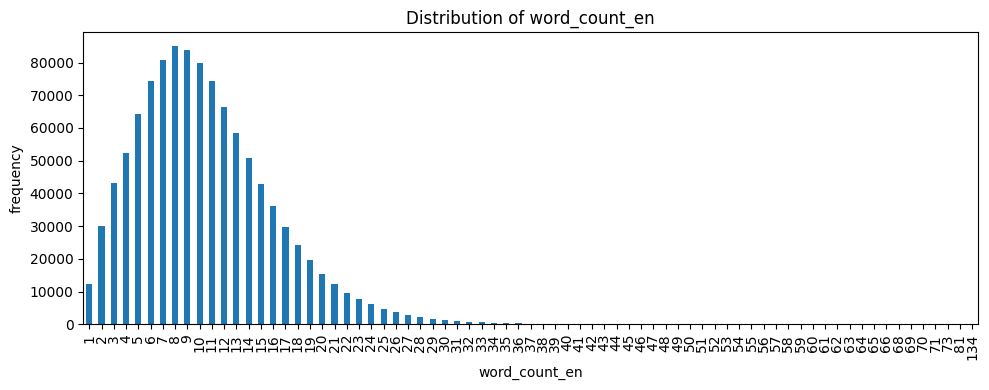

In [9]:
# word_count_en
counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

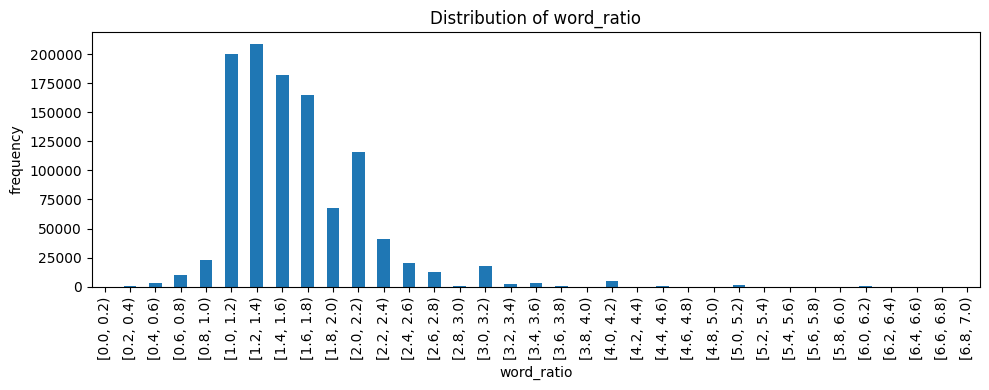

In [10]:
# word_ratio
import numpy as np

bins = np.arange(0, 7.2, 0.2)
groups = pd.cut(train_df["word_ratio"], bins=bins, right=False)

counts = groups.value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_ratio")
plt.ylabel("frequency")
plt.title("Distribution of word_ratio")
plt.tight_layout()

plt.show()

In [11]:
train_df = train_df[train_df["word_count_ko"] <= 25]
train_df = train_df[train_df["word_count_en"] <= 35]
train_df = train_df[train_df["word_ratio"] <= 3.5]

train_df = train_df.drop(
    ["word_count_ko", "word_count_en", "word_ratio"]
    , axis=1
    )

### 도메인 맵핑

In [12]:
DOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["subdomain"])}

DOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(DOMAIN_KEY_MAP)
train_df["subdomain"] = train_df['subdomain'].map(SUBDOMAIN_KEY_MAP)

In [13]:
train_df = train_df.reset_index().drop("index", axis=1)

In [14]:
TRAIN_DICT = train_df.to_dict("index")
print(f"· 가공 후 데이터: {len(TRAIN_DICT)}개")

· 가공 후 데이터: 1070866개


In [15]:
rand_idx = random.randint(1, len(TRAIN_DICT)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DICT[rand_idx]

[가공 후 샘플 출력]
key: 238227


{'domain': 2,
 'subdomain': 5,
 'ko_original': '1080p, 720p, 420p 카메라가 있죠.',
 'en': 'We have 1080p, 720p, and 420p cameras.',
 'ner': None}

# 실험 계획

1. ner 있는 데이터의 최소 오류만 보정하여 데이터로 이용.

- 텍스트

- 도메인 + 텍스트

- ner + 텍스트 

- 도메인 + ner +텍스트

In [16]:
NER_TRAIN_DICT = dict()

for key, value in TRAIN_DICT.items():
    if value["ner"]:
        NER_TRAIN_DICT[key] = value

In [17]:
len(NER_TRAIN_DICT)

32914

In [18]:
unique_ner_tag_set = set()

for value in NER_TRAIN_DICT.values():
    tag_dict_list = value["ner"]["tags"]
    for tag_dict in tag_dict_list:
        unique_ner_tag_set.add(tag_dict["tag"])

unique_ner_tag_set

{'ORG', 'PERSON', 'PRODUCT', 'WORK_OF_ART'}

In [19]:
NER_TRAIN_DICT

{25: {'domain': 0,
  'subdomain': 7,
  'ko_original': '>와우영미.',
  'en': '> WaWooYoungmi.',
  'ner': {'text': '>와우<PERSON>영미</PERSON>.',
   'tags': [{'tag': 'PERSON', 'value': '영미', 'position': '[3, 5]'}]}},
 39: {'domain': 0,
  'subdomain': 10,
  'ko_original': '>야, 석진이 형 뒤에 안 했다.',
  'en': ">Hey, Seok-jin didn't do it behind.",
  'ner': {'text': '>야, <PERSON>석진이</PERSON> 형 뒤에 안 했다.',
   'tags': [{'tag': 'PERSON', 'value': '석진이', 'position': '[4, 7]'}]}},
 163: {'domain': 2,
  'subdomain': 6,
  'ko_original': '일라이: 니모는 얼마나 깊이 들어갈 수 있고 배터리 팩은 얼마나 오래 지속되나요?',
  'en': 'Eli: How deep can Nemo go and how long does its battery pack last?',
  'ner': {'text': '<PERSON>일라이</PERSON>: <PRODUCT>니모</PRODUCT>는 얼마나 깊이 들어갈 수 있고 배터리 팩은 얼마나 오래 지속되나요?',
   'tags': [{'tag': 'PRODUCT', 'value': '니모', 'position': '[5, 7]'},
    {'tag': 'PERSON', 'value': '일라이', 'position': '[0, 3]'}]}},
 178: {'domain': 1,
  'subdomain': 1,
  'ko_original': '혹시 그냥 엑셀 파일로 저희에게 보내주실수 있을까요?',
  'en': 'Can you just send us an E

In [20]:
import re

for key, info_dict in NER_TRAIN_DICT.items():
    text = info_dict["ner"]["text"]
    
    text = re.sub(r'(<\w+?>)\s+([^<]*?)(</\w+?>)', r' \1\2\3', text)
    text = re.sub(r'(<\w+?>)([^<]*?)\s+(</\w+?>)', r'\1\2\3 ', text)
        
    info_dict["ner_text"] = text

    del info_dict["ner"]

---

In [21]:
ner_train_json_path = os.path.join(DATA_DIR, "NER_TRAIN.json")

with open(ner_train_json_path, "w", encoding="utf-8") as f:
    json.dump(NER_TRAIN_DICT, f, indent=4, ensure_ascii=False)

In [22]:
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast

NER_TRAIN_JSON_PATH = os.path.join(DATA_DIR, "NER_TRAIN.json")
CHECKPOINT_ROOT = Path("checkpoints")
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_DIR = None  # optional external checkpoint directory
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

with open(NER_TRAIN_JSON_PATH, encoding="utf-8") as f:
    RAW_RECORDS: List[Dict] = list(json.load(f).values())

print(f"Loaded {len(RAW_RECORDS)} samples")
print("Sample keys:", RAW_RECORDS[0].keys())

Loaded 32914 samples
Sample keys: dict_keys(['domain', 'subdomain', 'ko_original', 'en', 'ner_text'])


In [ ]:
RAW_RECORDS[0]

In [23]:
def normalize(text: str) -> str:
    return " ".join((text or "").strip().split())

def build_domain_token_map(records: Sequence[Dict]) -> Dict[int, str]:
    domain_ids = sorted({int(sample["domain"]) for sample in records})
    return {domain_id: f"<DOMAIN_{domain_id}>" for domain_id in domain_ids}

def extract_ner_special_tokens(records: Sequence[Dict]) -> List[str]:
    pattern = re.compile(r"(</?\w+?>)")
    specials = set()
    for sample in records:
        for tag in pattern.findall(sample.get("ner_text") or ""):
            specials.add(tag)
    return sorted(specials)

DOMAIN_TOKEN_MAP = build_domain_token_map(RAW_RECORDS)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-multilingual-cased")
tokenizer.add_special_tokens({
    "additional_special_tokens": list(DOMAIN_TOKEN_MAP.values()) + extract_ner_special_tokens(RAW_RECORDS)
})
PAD_ID = tokenizer.pad_token_id
VOCAB_SIZE = tokenizer.get_vocab_size(with_added_tokens=True)

class TranslationDataset(Dataset):
    def __init__(self, records, setting):
        self.records = records
        self.setting = setting

    def __len__(self): return len(self.records)

    def _build_source(self, sample: Dict) -> str:
        parts = []
        if self.setting["use_domain_prefix"]:
            parts.append(DOMAIN_TOKEN_MAP[int(sample["domain"])])
        base = sample["ner_text"] if self.setting["use_ner_text"] else sample["ko_original"]
        parts.append(normalize(base))
        return " ".join(parts)

    def __getitem__(self, idx):
        sample = self.records[idx]
        src_text = self._build_source(sample)
        tgt_text = normalize(sample["en"])

        src = tokenizer(src_text, truncation=True, max_length=self.setting["src_max_len"])
        tgt = tokenizer(tgt_text, truncation=True, max_length=self.setting["tgt_max_len"])

        return {
            "input_ids": torch.tensor(src["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(src["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(tgt["input_ids"], dtype=torch.long),
        }

def pad_sequences(tensors: List[torch.Tensor], pad_value: int) -> torch.Tensor:
    max_len = max(len(t) for t in tensors)
    batch = torch.full((len(tensors), max_len), pad_value, dtype=torch.long)
    for i, t in enumerate(tensors):
        batch[i, : len(t)] = t
    return batch

def collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    return {
        "input_ids": pad_sequences([item["input_ids"] for item in batch], PAD_ID),
        "attention_mask": pad_sequences([item["attention_mask"] for item in batch], 0),
        "labels": pad_sequences([item["labels"] for item in batch], PAD_ID),
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [24]:
DOMAIN_TOKEN_MAP

{0: '<DOMAIN_0>', 1: '<DOMAIN_1>', 2: '<DOMAIN_2>'}

In [ ]:
class Seq2SeqGRU(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, pad_id: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.decoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, src_ids: torch.Tensor, tgt_ids: torch.Tensor):
        _, hidden = self.encoder(self.embedding(src_ids))
        decoder_inputs = tgt_ids[:, :-1]
        decoder_outputs, _ = self.decoder(self.embedding(decoder_inputs), hidden)
        return self.proj(decoder_outputs)

def compute_loss(logits: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
    targets = tgt_ids[:, 1:]
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=PAD_ID,
    )

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for batch in loader:
        src_ids = batch["input_ids"].to(DEVICE)
        tgt_ids = batch["labels"].to(DEVICE)
        logits = model(src_ids, tgt_ids)
        total += compute_loss(logits, tgt_ids).item()
    return total / len(loader)

In [ ]:
import shutil

EXPERIMENT_VARIANTS = {
    "text_only": {"use_domain_prefix": False, "use_ner_text": False, "src_max_len": 96, "tgt_max_len": 96},
    "domain_text": {"use_domain_prefix": True, "use_ner_text": False, "src_max_len": 100, "tgt_max_len": 96},
    "ner_text_only": {"use_domain_prefix": False, "use_ner_text": True, "src_max_len": 110, "tgt_max_len": 96},
    "domain_ner_text": {"use_domain_prefix": True, "use_ner_text": True, "src_max_len": 120, "tgt_max_len": 96},
}

class ExperimentRunner:
    def __init__(
        self,
        records: List[Dict],
        variant_name: str,
        drive_dir=None,
        batch_size=64,
        embed_dim=256,
        hidden_dim=512,
        lr=3e-4,
        epochs=5,
        patience=2,
        early_stop_delta=0.0,
    ):
        assert variant_name in EXPERIMENT_VARIANTS, f"Unknown variant {variant_name}"
        self.variant_name = variant_name
        self.setting = EXPERIMENT_VARIANTS[variant_name]
        self.batch_size = batch_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.early_stop_delta = early_stop_delta

        self.train_records, self.val_records = self._split(records)
        self.train_loader = self._build_loader(self.train_records, shuffle=True)
        self.val_loader = self._build_loader(self.val_records, shuffle=False)

        self.model = Seq2SeqGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        self.ckpt_dir = CHECKPOINT_ROOT / variant_name
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        self.drive_dir = Path(drive_dir) if drive_dir else None
        if self.drive_dir:
            self.drive_dir.mkdir(parents=True, exist_ok=True)

        self.history_path = self.ckpt_dir / "metrics.json"
        self.drive_history_path = (
            self.drive_dir / f"{variant_name}_metrics.json" if self.drive_dir else None
        )
        self.best_ckpt_path = self.ckpt_dir / "best.pt"
        self.drive_best_ckpt_path = (
            self.drive_dir / f"{self.variant_name}_best.pth" if self.drive_dir else None
        )
        self.best_val_loss = float("inf")
        self.epochs_without_improve = 0

    def _split(self, records, val_ratio=0.1):
        shuffled = records[:]
        random.shuffle(shuffled)
        val_size = int(len(shuffled) * val_ratio)
        return shuffled[val_size:], shuffled[:val_size]

    def _build_loader(self, records, shuffle):
        dataset = TranslationDataset(records, self.setting)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle, collate_fn=collate_fn)

    def _save_checkpoint(self, history: List[Dict], state: Dict, is_best: bool):
        torch.save(state, self.ckpt_dir / "last.pth")

        with open(self.history_path, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        if self.drive_dir:
            shutil.copy(self.ckpt_dir / "last.pth", self.drive_dir / f"{self.variant_name}_last.pth")
            with open(self.drive_history_path, "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)

        if is_best:
            shutil.copy(self.ckpt_dir / "last.pth", self.best_ckpt_path)
            if self.drive_best_ckpt_path:
                shutil.copy(self.ckpt_dir / "last.pth", self.drive_best_ckpt_path)

    def run(self):
        history = []
        for epoch in range(1, self.epochs + 1):
            self.model.train()
            total_loss = 0.0
            for batch in self.train_loader:
                src_ids = batch["input_ids"].to(DEVICE)
                tgt_ids = batch["labels"].to(DEVICE)
                self.optimizer.zero_grad()
                logits = self.model(src_ids, tgt_ids)
                loss = compute_loss(logits, tgt_ids)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                total_loss += loss.item()

            train_loss = total_loss / len(self.train_loader)
            val_loss = evaluate(self.model, self.val_loader)
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

            state = {
                "epoch": epoch,
                "model_state": self.model.state_dict(),
                "optimizer_state": self.optimizer.state_dict(),
                "history": history,
            }

            is_best = val_loss < (self.best_val_loss - self.early_stop_delta)
            if is_best:
                self.best_val_loss = val_loss
                self.epochs_without_improve = 0
            else:
                self.epochs_without_improve += 1

            self._save_checkpoint(history, state, is_best)
            print(f"[{self.variant_name}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}" + (" <- best" if is_best else ""))

            if self.patience is not None and self.epochs_without_improve >= self.patience:
                print(f"[{self.variant_name}] early stopping triggered (best val {self.best_val_loss:.4f})")
                break



In [ ]:
TARGET_VARIANT = "text_only"  # choose one from: text_only, domain_text, ner_text_only, domain_ner_text
NUM_EPOCHS = 5

runner = ExperimentRunner(
    RAW_RECORDS,
    variant_name=TARGET_VARIANT,
    drive_dir=DRIVE_DIR,
    epochs=NUM_EPOCHS,
)
runner.run()


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [28]:
# ner_dict = dict()

# for key, value in TRAIN_DICT.items():
#     if value["ner"]:
#         tag_list = value["ner"]["tags"]

#         for tag_dict in tag_list:
#             position_str = tag_dict["position"]
#             tag_dict["position"] = [int(idx) for idx in position_str.strip("[]").split(",")]

#         ner_dict[key] = value["ner"]

In [29]:
# ner_dict

In [30]:
# unique_ner_tag_set = set()

# for value in ner_dict.values():
#     for tag_dict in value["tags"]:
#         unique_ner_tag_set.add(tag_dict["tag"])

# unique_ner_tag_set

1. text_value에 문제가 없다면 바로 올리기

   1. tag_count와 actual_tag_count 비교: actual이 더 적으면 추가해야 함. 그럼 바로 올릴 자격 됨. -> 자격 안 되는 경우는 없었음.
   2. tag 정보 구체적일 필요 없고, value 좌우에 공백만 없으면 됨.

2. 

In [31]:
# import re

# ner_tag_err_dict = dict()
# ner_count_err_dict = dict()

# for key, value in ner_dict.items():
#     text = value["text"]
#     tag_list = value["tags"]

#     tag_count = len(tag_list)
#     actual_tag_count = sum(1 for _ in re.finditer(r"<\w+>", text))

#     if tag_count != actual_tag_count:
#         ner_count_err_dict[key] = value

#     err_tag_list = list()

#     for tag_dict in tag_list:
#         tag = tag_dict["tag"]
#         text_value = tag_dict["value"]

#         pattern = rf"<{re.escape(tag)}>{re.escape(text_value)}</{re.escape(tag)}>"
#         if not re.search(pattern, text):
#             err_tag_list.append(tag_dict)

#     if err_tag_list:
#         ner_tag_err_dict[key] = {
#             "text": text,
#             "tags": err_tag_list
#             }
        
# print("[NER 오류]")
# print(f"· 표기 오류: {len(ner_tag_err_dict)}개")
# print(f"· 누락 오류: {len(ner_count_err_dict)}개")

In [32]:
# ner_count_err_dict

In [33]:
# ## TODO: 위치 기반까지 에러 추적하기
# ner_position_err_dict = dict()

# for key, value in ner_dict.items():
#     text = value["text"]
#     tag_list = value["tags"]

#     if len(tag_list) > 1:
#         continue

#     err_tag_list = list()

#     for tag_dict in tag_list:
#         tag = tag_dict["tag"]
#         text_value = tag_dict["value"]
        
#         pattern = f"<{tag}>{text_value}</{tag}>"

#         try: 
#             position = tag_dict["position"]
#             start_position = position[0]
#             if text[start_position: start_position + len(pattern)] != pattern:
#                 err_tag_list.append(tag_dict)

#         except:
#             err_tag_list.append(tag_dict)


#     if err_tag_list:
#         ner_position_err_dict[key] = {
#             "text": text,
#             "tags": err_tag_list
#             }

# print("[NER 오류]")
# print(f"· 오류: {len(ner_position_err_dict)}개")

# # ner_position_err_dict

In [34]:
# ner_err_json_path = os.path.join(DATA_DIR, "ner_err.json")

# with open(ner_err_json_path, "w", encoding="utf-8") as f:
#     json.dump(ner_tag_err_dict, f, indent=4, ensure_ascii=False)

In [35]:
# len(set(ner_tag_err_dict) - set(ner_position_err_dict))
# len(set(ner_position_err_dict) - set(ner_tag_err_dict))

# 학습 결과 비교: 추론 샘플 & 손실 곡선


In [ ]:
import math
from collections import defaultdict


def load_checkpoint(variant_name: str, ckpt_name: str = "best.pt"):
    ckpt_path = CHECKPOINT_ROOT / variant_name / ckpt_name
    if not ckpt_path.exists():
        raise FileNotFoundError(f"{ckpt_path} not found; 먼저 해당 실험을 학습시키세요")
    state = torch.load(ckpt_path, map_location=DEVICE)

    embed_dim = runner.embed_dim if "runner" in globals() else 256
    hidden_dim = runner.hidden_dim if "runner" in globals() else 512
    model = Seq2SeqGRU(VOCAB_SIZE, embed_dim, hidden_dim, PAD_ID).to(DEVICE)
    model.load_state_dict(state["model_state"])
    model.eval()

    history_path = ckpt_path.parent / "metrics.json"
    history = []
    if history_path.exists():
        with open(history_path, encoding="utf-8") as f:
            history = json.load(f)
    return model, history


@torch.no_grad()
def greedy_decode(model: nn.Module, src_text: str, max_len: int = 96):
    tokenized = tokenizer(src_text, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    src_ids = tokenized.input_ids
    _, hidden = model.encoder(model.embedding(src_ids))

    prev_token = torch.tensor([[tokenizer.cls_token_id]], device=DEVICE)
    outputs = []
    for _ in range(max_len):
        decoder_output, hidden = model.decoder(model.embedding(prev_token), hidden)
        logit = model.proj(decoder_output[:, -1])
        next_id = logit.argmax(dim=-1)
        token_id = next_id.item()
        if token_id == tokenizer.sep_token_id:
            break
        outputs.append(token_id)
        prev_token = next_id.unsqueeze(0)
    return tokenizer.decode(outputs, skip_special_tokens=True).strip()


def build_source_text(sample: Dict, variant_name: str) -> str:
    setting = EXPERIMENT_VARIANTS[variant_name]
    parts = []
    if setting["use_domain_prefix"]:
        parts.append(DOMAIN_TOKEN_MAP[int(sample["domain"])])
    base = sample["ner_text"] if setting["use_ner_text"] else sample["ko_original"]
    parts.append(normalize(base))
    return " ".join(parts)


def compare_variants(variant_names: List[str], sample_indices: List[int]):
    results = defaultdict(list)
    histories = {}
    for variant in variant_names:
        model, history = load_checkpoint(variant)
        histories[variant] = history
        setting = EXPERIMENT_VARIANTS[variant]
        best_val = history[-1]["val_loss"] if history else float("nan")
        print(f"\n[{variant}] best val loss: {best_val}")
        for idx in sample_indices:
            sample = RAW_RECORDS[idx]
            src_text = build_source_text(sample, variant)
            pred = greedy_decode(model, src_text, max_len=setting["tgt_max_len"])
            results[variant].append({
                "domain": int(sample["domain"]),
                "source": sample["ko_original"],
                "target": sample["en"],
                "prediction": pred,
            })
    return results, histories


def plot_loss_curves(histories: Dict[str, List[Dict]]):
    plt.figure(figsize=(8,4))
    for variant, hist in histories.items():
        if not hist:
            continue
        epochs = [item["epoch"] for item in hist]
        train_losses = [item["train_loss"] for item in hist]
        val_losses = [item["val_loss"] for item in hist]
        plt.plot(epochs, val_losses, marker="o", label=f"{variant} (val)")
        plt.plot(epochs, train_losses, linestyle="--", alpha=0.5, label=f"{variant} (train)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 사용 예시
# variants_to_compare = ["text_only", "domain_text", "ner_text_only", "domain_ner_text"]
# sample_indices = [0, 10, 20]
# inference_results, histories = compare_variants(variants_to_compare, sample_indices)
# for variant, items in inference_results.items():
#     print(f"\n== {variant} ==")
#     for item in items:
#         print(f"[DOMAIN {item['domain']}]\nSRC: {item['source']}\nTGT: {item['target']}\nPRED: {item['prediction']}\n")
# plot_loss_curves(histories)
